In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [14]:
# Keep only strains E and G
df = mice[mice['strain'].isin(['E', 'G'])]

df.head()


,mouse_id,strain,maze_test,object_recognition,fear_conditioning,social_memory,BDNF,CREB1,DRD2,GRIN1,diet,light_hours,exercise_wheel,age_weeks,weight_g
60,M061,E,85,65,55,60,9.0,5.8,5.2,6.0,standard,16,yes,12,27.0
61,M062,E,88,68,58,63,9.3,6.1,5.0,6.3,standard,16,yes,14,27.7
62,M063,E,82,62,52,57,8.7,5.5,5.4,5.7,standard,16,no,11,26.3
63,M064,E,86,66,56,61,9.1,5.9,5.1,6.1,enriched,16,yes,13,26.6
64,M065,E,84,64,54,59,8.9,5.7,5.3,5.9,standard,16,no,12,27.4


In [3]:
import pandas as pd

infile = "https://raw.githubusercontent.com/cgenomicslab/Courses/refs/heads/main/MScNeuro/2026/data/mouse_cognition.csv"
mice = pd.read_csv(infile)

mice.head()



,mouse_id,strain,maze_test,object_recognition,fear_conditioning,social_memory,BDNF,CREB1,DRD2,GRIN1,diet,light_hours,exercise_wheel,age_weeks,weight_g
0,M001,A,78,72,65,70,8.2,6.5,5.8,7.1,standard,12,yes,12,28.5
1,M002,A,82,75,68,73,8.5,6.8,5.6,7.4,standard,12,yes,14,29.2
2,M003,A,75,70,62,68,7.9,6.3,5.9,6.9,standard,12,no,11,27.8
3,M004,A,80,74,66,71,8.3,6.6,5.7,7.2,enriched,12,yes,13,28.1
4,M005,A,77,71,64,69,8.1,6.4,5.8,7.0,standard,12,no,12,28.9


In [15]:
df.groupby('strain')['maze_test'].describe()


,count,mean,std,min,25%,50%,75%,max
strain,,,,,,,,
E,15.0,85.8,3.277630,80.0,83.5,86.0,88.0,91.0
G,15.0,72.6,3.224903,67.0,70.5,73.0,74.5,78.0


In [6]:
mice.columns


Index(['mouse_id', 'strain', 'maze_test', 'object_recognition',
       'fear_conditioning', 'social_memory', 'BDNF', 'CREB1', 'DRD2', 'GRIN1',
       'diet', 'light_hours', 'exercise_wheel', 'age_weeks', 'weight_g'],
      dtype='object')

In [7]:
df = mice[mice["strain"].isin(["E", "G"])].copy()

df.head()


,mouse_id,strain,maze_test,object_recognition,fear_conditioning,social_memory,BDNF,CREB1,DRD2,GRIN1,diet,light_hours,exercise_wheel,age_weeks,weight_g
60,M061,E,85,65,55,60,9.0,5.8,5.2,6.0,standard,16,yes,12,27.0
61,M062,E,88,68,58,63,9.3,6.1,5.0,6.3,standard,16,yes,14,27.7
62,M063,E,82,62,52,57,8.7,5.5,5.4,5.7,standard,16,no,11,26.3
63,M064,E,86,66,56,61,9.1,5.9,5.1,6.1,enriched,16,yes,13,26.6
64,M065,E,84,64,54,59,8.9,5.7,5.3,5.9,standard,16,no,12,27.4


In [8]:
df.groupby("strain")["maze_test"].describe()


,count,mean,std,min,25%,50%,75%,max
strain,,,,,,,,
E,15.0,85.8,3.277630,80.0,83.5,86.0,88.0,91.0
G,15.0,72.6,3.224903,67.0,70.5,73.0,74.5,78.0


In [9]:
summary = df.groupby("strain")["maze_test"].agg(
    mean="mean",
    median="median",
    std="std",
    n="count"
)
summary


,mean,median,std,n
strain,,,,
E,85.8,86.0,3.277630,15
G,72.6,73.0,3.224903,15


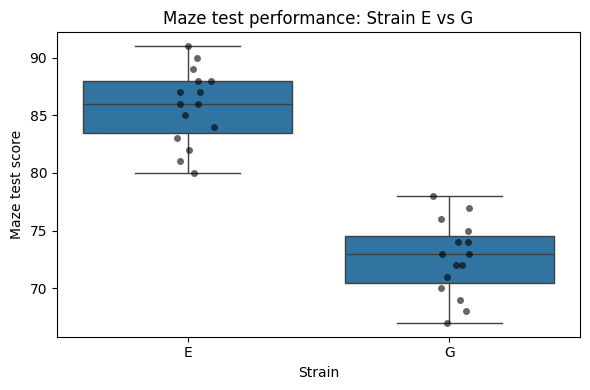

In [10]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="strain", y="maze_test")
sns.stripplot(data=df, x="strain", y="maze_test", color="black", alpha=0.6)

plt.title("Maze test performance: Strain E vs G")
plt.xlabel("Strain")
plt.ylabel("Maze test score")
plt.tight_layout()
plt.show()


In [16]:
# Normality test (Shapiro–Wilk)
E = df[df["strain"] == "E"]["maze_test"]
G = df[df["strain"] == "G"]["maze_test"]

shapiro_E = stats.shapiro(E)
shapiro_G = stats.shapiro(G)

shapiro_E, shapiro_G


(ShapiroResult(statistic=np.float64(0.9713532238711695), pvalue=np.float64(0.8775668087117316)),
 ShapiroResult(statistic=np.float64(0.9809963704021896), pvalue=np.float64(0.975843588292818)))

Normality assessment

Normality of maze test scores was assessed using the Shapiro–Wilk test.
Both strain E (p = 0.88) and strain G (p = 0.98) showed p-values greater than 0.05,
indicating that the data do not significantly deviate from a normal distribution.


In [17]:
t_stat, p_ttest = stats.ttest_ind(E, G, equal_var=False)
t_stat, p_ttest


(np.float64(11.118282970684648), np.float64(8.847316306369144e-12))

Statistical comparison and interpretation

Maze test performance was compared between strain E and strain G using an
independent samples t-test, as both groups followed a normal
distribution (Shapiro–Wilk test, p > 0.05). The analysis revealed a highly
statistically significant difference (t = 11.12, p = 8.8 × 10⁻¹²), with strain E
showing higher maze test scores than strain G.
